In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib
import spearman_plotting_func as spearman_plotting
import setup_paths as paths
import matplotlib.pyplot as plt



In [4]:

matplotlib.rcParams.update({'font.size': 14})


In [5]:

filenames = os.listdir(paths.base_path + '/paper_data/')


In [6]:

min_dist = 0
max_dist = 200
n_stations = 1



In [37]:
paths.base_path + '/paper_data/'

'/home/earthquakes1/homes/Rebecca/phd/seismo_det/code/../paper_data/'

In [40]:
filenames_use = [filenames[2], filenames[6], filenames[11], filenames[16]]

In [41]:
filenames_use

['eq_object_03s_bandpass_01_19_snr_20_blank_0_new_snr20',
 'eq_object_05s_bandpass_01_19_snr_20_blank_0_new_snr20',
 'eq_object_1s_bandpass_01_19_snr_20_blank_0_new_snr20',
 'eq_object_4s_bandpass_01_19_snr_20_blank_0_new_snr20']

In [43]:
for f in filenames_use[0:1]:
    print(f)
    df = pd.read_pickle(f'{paths.base_path}/paper_data/eq_object_03s_bandpass_01_19_snr_20_blank_0_new_snr20')
    df

eq_object_03s_bandpass_01_19_snr_20_blank_0_new_snr20


In [ ]:
tp_loss_significance = []
tc_loss_significance = []
pgd_loss_significance = []
iv2_loss_significance = []

n_stations_list = []
min_dist_list = []
max_dist_list = []

tp_n = []
tc_n = []
pgd_n = []
iv2_n = []

for f in filenames_use[0:1]:
    print(f)
    df = pd.read_pickle(f'{paths.base_path}/paper_data/{f}')

    # can run for multiple (minimum) n_stations and min_dist, but for now just look at all data
    for n_stations in range(1, 7):
        for min_dist in range(0, 100, 10):
            for max_dist in range(0, 200, 10):
                if min_dist >= max_dist:
                    continue
                print(f'n_stations: {n_stations}, min_dist: {min_dist}, max_dist: {max_dist}')

                # prepare data
                options = {'n': n_stations, 'min_dist': min_dist, 'max_dist': max_dist}
                x_tp, y_tp = spearman_plotting.calc_tp_mag_lim(df, 3., **options)
                x_pgd, y_pgd = spearman_plotting.calc_pgd_mag_lim(df, 3., **options)
                x_tc, y_tc = spearman_plotting.calc_tc_mag_lim(df, 3., **options)
                x_iv2, y_iv2 = spearman_plotting.calc_iv2_mag_lim(df, 3., **options)

                # predominant period
                # define empty lists to store the results
                gradt, intercept, gradt_std, intercept_std = [], [], [], []
                pearson = []
                spearman = []
                spearman_p = []
                n_l = []

                # loop over magnitudes and calculate statistical values for each. append to lists just defined.
                for mag_lim in spearman_plotting.magnitudes:
                    x, y = spearman_plotting.calc_tp_mag_lim(df, mag_lim, **options)
                    output = spearman_plotting.calc_opt(x, y,
                                                        gradt,
                                                        intercept,
                                                        gradt_std,
                                                        intercept_std,
                                                        pearson,
                                                        spearman,
                                                        spearman_p,
                                                        n_l)
                    gradt, intercept, gradt_std, intercept_std, pearson, spearman, spearman_p, n = output
                tp_params = [gradt, gradt_std, np.array(pearson)**2, spearman, spearman_p, n, 'tp']

                # average period
                # define empty lists to store the results
                gradt, intercept, gradt_std, intercept_std = [], [], [], []
                pearson = []
                spearman = []
                spearman_p = []
                n_l = []
                # loop over magnitudes and calculate statistical values for each. append to lists just defined.
                for mag_lim in spearman_plotting.magnitudes:
                    x, y = spearman_plotting.calc_tc_mag_lim(df, mag_lim, **options)
                    output = spearman_plotting.calc_opt(x, y,
                                                        gradt,
                                                        intercept,
                                                        gradt_std,
                                                        intercept_std,
                                                        pearson,
                                                        spearman,
                                                        spearman_p,
                                                        n_l)
                    gradt, intercept, gradt_std, intercept_std, pearson, spearman, spearman_p, n = output
                tc_params = [gradt, gradt_std, np.array(pearson)**2, spearman, spearman_p, n, 'tc']

                # peak ground displacement
                # define empty lists to store the results
                gradt, intercept, gradt_std, intercept_std = [], [], [], []
                pearson = []
                spearman = []
                spearman_p = []
                n_l = []

                # loop over magnitudes and calculate statistical values for each. append to lists just defined.
                for mag_lim in spearman_plotting.magnitudes:
                    x, y = spearman_plotting.calc_pgd_mag_lim(df, mag_lim, **options)
                    output = spearman_plotting.calc_opt(x, y,
                                                        gradt,
                                                        intercept,
                                                        gradt_std,
                                                        intercept_std,
                                                        pearson,
                                                        spearman,
                                                        spearman_p,
                                                        n_l)
                    gradt, intercept, gradt_std, intercept_std, pearson, spearman, spearman_p, n = output
                pgd_params = [gradt, gradt_std, np.array(pearson)**2, spearman, spearman_p, n, 'pgd']

                # iv2
                # define empty lists to store the results
                gradt, intercept, gradt_std, intercept_std = [], [], [], []
                pearson = []
                spearman = []
                spearman_p = []
                n_l = []
                # loop over magnitudes and calculate statistical values for each. append to lists just defined.
                for mag_lim in spearman_plotting.magnitudes:
                    x, y = spearman_plotting.calc_iv2_mag_lim(df, mag_lim, **options)
                    output = spearman_plotting.calc_opt(x, y,
                                                        gradt,
                                                        intercept,
                                                        gradt_std,
                                                        intercept_std,
                                                        pearson,
                                                        spearman,
                                                        spearman_p,
                                                        n_l)
                    gradt, intercept, gradt_std, intercept_std, pearson, spearman, spearman_p, n = output
                iv2_params = [gradt, gradt_std, np.array(pearson)**2, spearman, spearman_p, n, 'iv2']
                
                tp_loss_significance.append(np.where(np.array(tp_params[4])>0.05)[0][0])
                tc_loss_significance.append(np.where(np.array(tc_params[4])>0.05)[0][0])
                pgd_loss_significance.append(np.where(np.array(pgd_params[4])>0.05)[0][0])
                iv2_loss_significance.append(np.where(np.array(iv2_params[4])>0.05)[0][0])
                
                tp_n.append(tp_params[5][np.where(np.array(tp_params[4])>0.05)[0][0]])
                tc_n.append(tc_params[5][np.where(np.array(tc_params[4])>0.05)[0][0]])
                pgd_n.append(pgd_params[5][np.where(np.array(pgd_params[4])>0.05)[0][0]])
                iv2_n.append(iv2_params[5][np.where(np.array(iv2_params[4])>0.05)[0][0]])
                
                n_stations_list.append(n_stations)
                min_dist_list.append(min_dist)
                max_dist_list.append(max_dist)

# Write min_dist_list to file
with open('min_dist_list.txt', 'w') as f:
	for item in min_dist_list:
		f.write("%s\n" % item)

# Write max_dist_list to file
with open('max_dist_list.txt', 'w') as f:
	for item in max_dist_list:
		f.write("%s\n" % item)

# Write tp_loss_significance to file
with open('tp_loss_significance.txt', 'w') as f:
	for item in tp_loss_significance:
		f.write("%s\n" % item)

# Write tc_loss_significance to file
with open('tc_loss_significance.txt', 'w') as f:
	for item in tc_loss_significance:
		f.write("%s\n" % item)

# Write iv2_loss_significance to file
with open('iv2_loss_significance.txt', 'w') as f:
	for item in iv2_loss_significance:
		f.write("%s\n" % item)

# Write pgd_loss_significance to file
with open('pgd_loss_significance.txt', 'w') as f:
	for item in pgd_loss_significance:
		f.write("%s\n" % item)

# Write n_stations_list to file
with open('n_stations_list.txt', 'w') as f:
	for item in n_stations_list:
		f.write("%s\n" % item)

# Write tp_n to file
with open('tp_n.txt', 'w') as f:
	for item in tp_n:
		f.write("%s\n" % item)

# Write tc_n to file
with open('tc_n.txt', 'w') as f:
	for item in tc_n:
		f.write("%s\n" % item)

# Write iv2_n to file
with open('iv2_n.txt', 'w') as f:
	for item in iv2_n:
		f.write("%s\n" % item)	

# Write pgd_n to file	
with open('pgd_n.txt', 'w') as f:
	for item in pgd_n:
		f.write("%s\n" % item)	


eq_object_03s_bandpass_01_19_snr_20_blank_005_new_snr20
n_stations: 1, min_dist: 0, max_dist: 10
n_stations: 1, min_dist: 0, max_dist: 20


KeyboardInterrupt: 

In [35]:
tp_loss_significance = []
tc_loss_significance = []
pgd_loss_significance = []
iv2_loss_significance = []

n_stations_list = []
min_dist_list = []
max_dist_list = []

tp_n = []
tc_n = []
pgd_n = []
iv2_n = []

for f in filenames[0:1]:
    print(f)
    df = pd.read_pickle(f'{paths.base_path}/paper_data/{f}')

    # can run for multiple (minimum) n_stations and min_dist, but for now just look at all data
    for n_stations in [1]:#range(1, 7):
        for min_dist in [0]: # range(0, 100, 10):
            for max_dist in [10, 100]:# range(0, 200, 10):
                if min_dist >= max_dist:
                    continue
                print(f'n_stations: {n_stations}, min_dist: {min_dist}, max_dist: {max_dist}')

                # prepare data
                options = {'n': n_stations, 'min_dist': min_dist, 'max_dist': max_dist}
                x_tp, y_tp = spearman_plotting.calc_tp_mag_lim(df, 3., **options)

                # predominant period
                # define empty lists to store the results
                gradt, intercept, gradt_std, intercept_std = [], [], [], []
                pearson = []
                spearman = []
                spearman_p = []
                n_l = []

                # loop over magnitudes and calculate statistical values for each. append to lists just defined.
                for mag_lim in spearman_plotting.magnitudes:
                    x, y = spearman_plotting.calc_tp_mag_lim(df, mag_lim, **options)
                    output = spearman_plotting.calc_opt(x, y,
                                                        gradt,
                                                        intercept,
                                                        gradt_std,
                                                        intercept_std,
                                                        pearson,
                                                        spearman,
                                                        spearman_p,
                                                        n_l)
                    gradt, intercept, gradt_std, intercept_std, pearson, spearman, spearman_p, n = output
                tp_params = [gradt, gradt_std, np.array(pearson)**2, spearman, spearman_p, n, 'tp']
                print(n)


eq_object_03s_bandpass_01_19_snr_20_blank_005_new_snr20
n_stations: 1, min_dist: 0, max_dist: 10
[394, 320, 266, 221, 189, 142, 115, 91, 80, 68, 62, 51, 46, 43, 39, 35, 34, 34, 34, 32, 25, 22, 17, 14, 11, 6, 3, 3, 2, 2]
n_stations: 1, min_dist: 0, max_dist: 100
[3098, 2899, 2727, 2585, 2463, 2344, 2250, 2185, 2144, 2105, 2058, 1994, 1927, 1839, 1741, 1654, 1602, 1575, 1540, 1510, 1179, 933, 702, 535, 408, 323, 258, 215, 167, 140, 116, 96, 75, 64, 51, 39, 30, 23, 17, 11, 8]


In [ ]:
#[gradt, gradt_std, np.array(pearson)**2, spearman, spearman_p, n, 'tp']

In [26]:
# Write min_dist_list to file
with open('min_dist_list.txt', 'w') as f:
	for item in min_dist_list:
		f.write("%s\n" % item)

# Write max_dist_list to file
with open('max_dist_list.txt', 'w') as f:
	for item in max_dist_list:
		f.write("%s\n" % item)

# Write tp_loss_significance to file
with open('tp_loss_significance.txt', 'w') as f:
	for item in tp_loss_significance:
		f.write("%s\n" % item)

# Write tc_loss_significance to file
with open('tc_loss_significance.txt', 'w') as f:
	for item in tc_loss_significance:
		f.write("%s\n" % item)

# Write iv2_loss_significance to file
with open('iv2_loss_significance.txt', 'w') as f:
	for item in iv2_loss_significance:
		f.write("%s\n" % item)

# Write pgd_loss_significance to file
with open('pgd_loss_significance.txt', 'w') as f:
	for item in pgd_loss_significance:
		f.write("%s\n" % item)

In [29]:
n_stations_list

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,


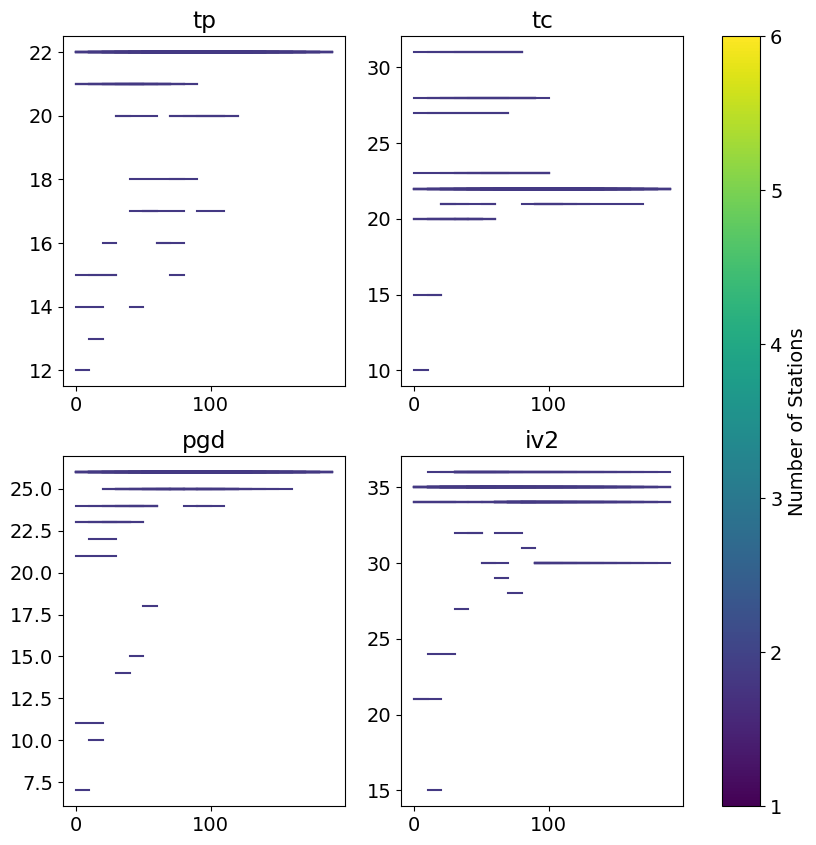

In [30]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
for i in range(0, len(tp_loss_significance)):
	color = plt.cm.viridis(n_stations_list[i] / max(n_stations_list))
	if n_stations_list[i] == 1:
		axs[0][0].plot([min_dist_list[i], max_dist_list[i]], [tp_loss_significance[i], tp_loss_significance[i]], color=color)
		axs[0][1].plot([min_dist_list[i], max_dist_list[i]], [tc_loss_significance[i], tc_loss_significance[i]], color=color)
		axs[1][0].plot([min_dist_list[i], max_dist_list[i]], [pgd_loss_significance[i], pgd_loss_significance[i]], color=color)
		axs[1][1].plot([min_dist_list[i], max_dist_list[i]], [iv2_loss_significance[i], iv2_loss_significance[i]], color=color)

#axs[0][0].scatter(max_dist_list, tp_loss_significance, color='k')
axs[0][0].set_title('tp')
axs[0][1].set_title('tc')
axs[1][0].set_title('pgd')
axs[1][1].set_title('iv2')

# Add colorbar
norm = plt.Normalize(vmin=min(n_stations_list), vmax=max(n_stations_list))
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axs, orientation='vertical', label='Number of Stations')

#plt.tight_layout()
plt.show()

In [15]:
np.where(np.array(tp_params[4])>0.05)[0][0]

22